# The Machine Learning Process 🌸
### Understanding the Stages of an ML Project (Iris Dataset)

Every ML project — no matter how advanced — follows roughly the same set of stages.
In this notebook, we'll walk through **each stage of the ML process**, one at a time,
using the Iris dataset as our running example.

**The 6 Stages we'll cover:**
1. Problem Definition
2. Data Collection
3. Data Preparation (cleaning, exploring)
4. Splitting the Data (Train/Test)
5. Model Training
6. Evaluation & Iteration

Understanding this pipeline matters more than any single algorithm — it's the workflow
you'll repeat in every ML project you ever build.


## Stage 1: Problem Definition

Before writing a single line of code, every ML project starts with a clear question:

> **"Given measurements of an iris flower, can we predict which species it is?"**

This is a **classification problem** — we're predicting a category (species), not a number.

Good problem definitions specify:
- **What are we predicting?** → the species (setosa, versicolor, virginica)
- **What do we have to predict it from?** → sepal length/width, petal length/width
- **What type of ML problem is this?** → Supervised classification (3 classes)

Skipping this step is one of the most common beginner mistakes — jumping straight to code
without being clear on what question you're actually answering.


## Stage 2: Data Collection

Next, we need data. In the real world, this stage can take weeks (sensors, surveys, databases, scraping).
For learning purposes, the Iris dataset is already collected and cleaned for us — it ships with scikit-learn.


In [ ]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = df_species = pd.Series(iris.target).map({0:'setosa', 1:'versicolor', 2:'virginica'})

print(f"Collected {df.shape[0]} samples with {df.shape[1]-1} features each.")
df.head()

Collected 150 samples with 4 features each.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


**Real-world note:** in practice, data collection also means asking:
- Is this data representative of what we'll see in the real world?
- Do we have enough samples?
- Is it labeled correctly?

150 flowers, 50 per species, is a small but clean dataset — great for learning, but real projects
often need thousands or millions of samples.


## Stage 3: Data Preparation

Raw data is rarely ready to feed into a model. This stage includes:
- **Checking for missing values**
- **Checking data types**
- **Exploring distributions and relationships** (to catch errors and understand the data)
- **Handling outliers or inconsistent entries**

Let's check our data health first.


In [ ]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Data types:")
print(df.dtypes)


Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Data types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object


1. Add a new preparation step: check if any two rows in the dataset are exact duplicates (`df.duplicated().sum()`).
- A duplicate was found in the dataset.

In [ ]:
# Check duplicated rows
df.duplicated().sum()

np.int64(1)

Good news — no missing values, and all measurement columns are numeric floats, exactly what we need.
In a messier dataset, this stage might involve filling missing values, removing duplicates,
or converting text categories into numbers.


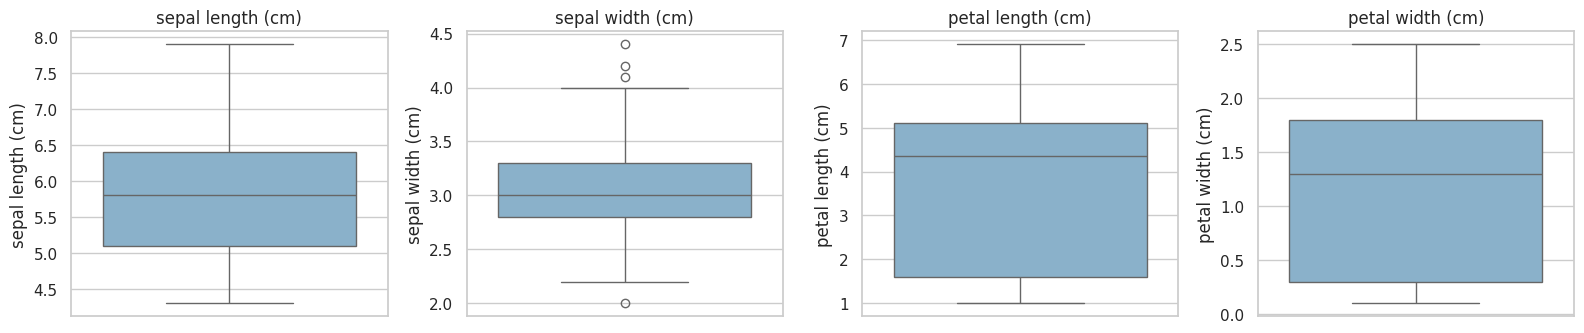

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# Quick visual check: does the data look reasonable? Any weird outliers?
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, col in zip(axes, iris.feature_names):
    sns.boxplot(y=df[col], ax=ax, color="#7FB3D5")
    ax.set_title(col)
plt.tight_layout()
plt.show()


Boxplots are a quick way to sanity-check for outliers. Here, the measurements all look reasonable
(no impossible values like negative lengths or absurd outliers) — this data is ready to move forward.


## Stage 4: Splitting the Data (Train / Test)

Before training a model, we set aside a portion of the data purely for **testing** —
data the model will *never* see during training. This lets us honestly check how well
the model generalizes to new, unseen flowers.

*(We'll go much deeper on this in the "Training, Testing & Evaluation" notebook — for now, just know
this stage exists and comes right after data preparation.)*


In [ ]:
from sklearn.model_selection import train_test_split

X = df[iris.feature_names]
y = pd.Series(iris.target)

# Changed test size to 0.3
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")


Training samples: 105
Testing samples:  45


## Stage 5: Model Training

Now we choose an algorithm and let it *learn* patterns from the training data.
Here we'll use a simple **Decision Tree** — don't worry about how it works internally yet,
just focus on where this step fits in the overall process.


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

print("Model has been trained on the training data.")


Model has been trained on the training data.


## Stage 6: Evaluation & Iteration

Finally, we check how well the model performs on the **test set** (data it hasn't seen),
and decide whether to accept it, tune it, or go back to an earlier stage.


In [ ]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Test Accuracy: {accuracy:.2%}")


Test Accuracy: 97.78%


2. Change the `test_size` in Stage 4 to `0.3` — how does that affect Stage 6's accuracy?
- Changing the test size increased the test accuracy from 96.67% to 97.78%. This is made possible by the increase of the number of test data points while the used dataset composed of fewer data points.

**This is where the process becomes a loop, not a straight line.** If accuracy is too low, we might:
- Go back to **Stage 3** and engineer better features
- Go back to **Stage 5** and try a different algorithm or settings
- Go back to **Stage 2** and collect more data

ML projects are rarely a single pass through these steps — they're an iterative cycle of
**Define → Collect → Prepare → Split → Train → Evaluate → repeat.**


## Recap: The Full ML Process

| Stage | What Happens | What We Did Here |
|---|---|---|
| 1. Problem Definition | Decide what you're predicting and why | Predict iris species from measurements |
| 2. Data Collection | Gather the raw data | Loaded Iris dataset from scikit-learn |
| 3. Data Preparation | Clean, check, and explore the data | Checked nulls, types, boxplots |
| 4. Splitting | Separate train vs. test data | 80/20 split |
| 5. Training | Fit a model to the training data | Trained a Decision Tree |
| 6. Evaluation | Measure performance, decide next steps | Checked accuracy on test set |

---

## 🧪 Try It Yourself

1. Add a new preparation step: check if any two rows in the dataset are exact duplicates (`df.duplicated().sum()`).
2. Change the `test_size` in Stage 4 to `0.3` — how does that affect Stage 6's accuracy?
3. Try skipping Stage 3 (data preparation) mentally — what could go wrong if you never checked for missing values or outliers?
4. In your own words, write a one-sentence "problem definition" for a *different* dataset you're curious about (e.g. predicting house prices, spam detection).


Note: Numbers 1 & 2 in between model training phases.

3. Try skipping Stage 3 (data preparation) mentally — what could go wrong if you never checked for missing values or outliers?
- Skipping the data preparation phase in model training will lead to errors or lower test accuracy. Cleaning the data before training ensures that the model will come out as effective and reliable. Choosing the right algorithm used for the dataset can also help alleviate this issue.

4. In your own words, write a one-sentence "problem definition" for a *different* dataset you're curious about (e.g. predicting house prices, spam detection).
- Considering various game statistics and awards, which teams performed best in NBA history?

# Conclusion
The activity highlights the significant procedure in model training. The model training process must include the problem definition, data collection, data preparation, splitting the data to training and testing data, model training, and evaluation and iteration. The steps 1 to 3 are already familiar to me as they are mostly taught in the ETL process. The following steps were new to me as they already involved the model training phase.<br><br>
Here, it is important to remember that choosing the right data split and training algorithm will affect the test accuracy. An example of this is when I changed the data split from 80/20 to 70/30. I saw an increase in the test accuracy after this. As the dataset only contains 150 data points, the 70/30 split would be more approriate here. A decision tree algorithm was used in training the data and it was already approriate in the application. There are many possible algorithms that can be used in model training and we must learn how to choose the right algorithm for the right datasets.<br><br>
To conclude, the model training process is a significant standard and must be followed at all times.